#Competitive Threat and Market Share Loss Prediction

##Libraries

In [ ]:
# if kagglehub not found
!pip install --upgrade kagglehub

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from sklearn.model_selection import train_test_split

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import nltk

In [ ]:
news_path = kagglehub.dataset_download("miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests")

print("Path to dataset files:", news_path)

Using Colab cache for faster access to the 'massive-stock-news-analysis-db-for-nlpbacktests' dataset.
Path to dataset files: /kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests


In [ ]:
stock_path = kagglehub.dataset_download("ehallmar/daily-historical-stock-prices-1970-2018")

print("Path to dataset files:", stock_path)

Using Colab cache for faster access to the 'daily-historical-stock-prices-1970-2018' dataset.
Path to dataset files: /kaggle/input/daily-historical-stock-prices-1970-2018


##Dataset

In [ ]:
# news headlines
dataset_root = os.path.join(news_path, 'analyst_ratings_processed.csv')
news = pd.read_csv(dataset_root)
news

,Unnamed: 0,title,date,stock
0,0.0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A
1,1.0,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A
2,2.0,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A
3,3.0,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A
4,4.0,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A
...,...,...,...,...
1400464,1413844.0,Top Narrow Based Indexes For August 29,2011-08-29 10:41:00-04:00,ZX
1400465,1413845.0,Recap: Wednesday's Top Percentage Gainers and ...,2011-06-22 16:44:00-04:00,ZX
1400466,1413846.0,UPDATE: Oppenheimer Color on China Zenix Auto ...,2011-06-21 08:26:00-04:00,ZX
1400467,1413847.0,Oppenheimer Initiates China Zenix At Outperfor...,2011-06-21 05:59:00-04:00,ZX


In [ ]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400469 entries, 0 to 1400468
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Unnamed: 0  1399180 non-null  float64
 1   title       1400469 non-null  object 
 2   date        1399180 non-null  object 
 3   stock       1397891 non-null  object 
dtypes: float64(1), object(3)
memory usage: 42.7+ MB


In [ ]:
# historic stock prices
dataset_root = os.path.join(stock_path, 'historical_stock_prices.csv')
stock = pd.read_csv(dataset_root)
stock

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14
...,...,...,...,...,...,...,...,...
20973884,NZF,14.60,14.59,14.590000,14.58,14.62,137500,2018-08-20
20973885,NZF,14.60,14.58,14.580000,14.57,14.61,151200,2018-08-21
20973886,NZF,14.58,14.59,14.590000,14.57,14.63,185400,2018-08-22
20973887,NZF,14.60,14.57,14.570000,14.57,14.64,135600,2018-08-23


In [ ]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ GB


###Data Cleaning & Pre-processing

In [ ]:
# remove "unnameed: 0" column from news_df, duplicates as the index
news = news.drop('Unnamed: 0', axis=1)

In [ ]:
# remove any rows with null values from news_df
news.dropna(inplace=True)

In [ ]:
# remove duplicated rows
news.drop_duplicates(inplace=True)

In [ ]:
# remove any rows from news_df where title contains ticker name only
news = news[
    news['title'].str.contains(" ", na=False)
    #news['title'].str.len() > 5
]

In [ ]:
# reuncate "date" info to contain only YYYY-MM-DD from news_df, so take out the time
news['date'] = news['date'].str.split(' ').str[0]

In [ ]:
# remove any rows from news_df where the date exceeds date range of stock_df
news_start = news['date'].min()
news_end = news['date'].max()
print("Date range: ", news_start, " to ", news_end)

stock = stock[
    (stock['date'] >= news_start) &
    (stock['date'] <= news_end)
]

Date range:  2009-02-14  to  2020-06-11


In [ ]:
# remove any rows with null values from stock_df
stock.dropna(inplace=True)

/tmp/ipykernel_4344/1661684134.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock.dropna(inplace=True)


In [ ]:
# drop duplicates
stock.drop_duplicates(inplace=True)

/tmp/ipykernel_4344/1102340827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock.drop_duplicates(inplace=True)


In [ ]:
# remove any rows from stock_df where the date exceeds the date range of news_df
stock_start = stock['date'].min()
stock_end = stock['date'].max()
print("Date range: ", stock_start, " to ", stock_end)

news = news[
    (news['date'] >= stock_start) &
    (news['date'] <= stock_end)
]

Date range:  2009-02-17  to  2018-08-24


In [ ]:
# find stock tickers in common
news_ticker = news['stock'].unique()
stock_ticker = stock['ticker'].unique()

in_common = set(news_ticker).intersection(stock_ticker)

# remove rows from news_df where value in "stock" does not match "ticker" value in stock_df
news = news[news['stock'].isin(in_common)]

# remove rows from stock_df where value in "ticker" value does not match "stock" value in news_df
stock = stock[stock['ticker'].isin(in_common)]

In [ ]:
# sort news by date
news = news.sort_values(by='date')

In [ ]:
# Create the expected price column using each stock's closing price
stock["price"] = stock["close"]

In [ ]:
# by matching the date of the news headline and the stock ticker,
# add the prices of the stock from the past 3 days to new columns in news_df
## ex. news_date(2025-04-23); add values from stock_df with dates {2025-04-21,2025-04-22, 2025-04-23} to 3 new columns
stock["date"] = pd.to_datetime(stock["date"])
news["date"] = pd.to_datetime(news["date"])

price_lookup = stock.set_index(["ticker", "date"])["price"].to_dict()

news["today_price"] = [
    price_lookup.get((t, d))
    for t, d in zip(news["stock"], news["date"])
]

news["1ago_price"] = [
    price_lookup.get((t, d - timedelta(days=1)))
    for t, d in zip(news["stock"], news["date"])
]

news["2ago_price"] = [
    price_lookup.get((t, d - timedelta(days=2)))
    for t, d in zip(news["stock"], news["date"])
]

# by matching the date of the news headline and the stock ticker,
# add the next day's stock price to the news_df as a new column
## ex. news_date(2025-04-23); add values from stock_df with dates {2025-04-24} to a new column 'next_day'
news["nextday_price"] = [
    price_lookup.get((t, d + timedelta(days=1)))
    for t, d in zip(news["stock"], news["date"])
]

In [ ]:
news.dropna(inplace=True)

In [ ]:
# round prices to 4 decimal places
prices = ["today_price", "1ago_price", "2ago_price", "nextday_price"]

news[prices] = news[prices].round(4)

In [ ]:
# add column in news_df for whether stock prices went up or down
## ex. price from 1_day_ago is higher than price of next_day -> price_went_up column value = 1
## ex. price from 1_day_ago is lower than price of next_day -> price_went_up column value = 0
news['price_went_up'] = news['today_price'] > news['nextday_price']
news['price_went_up'] = news['price_went_up'].astype(int)

##Visualizations

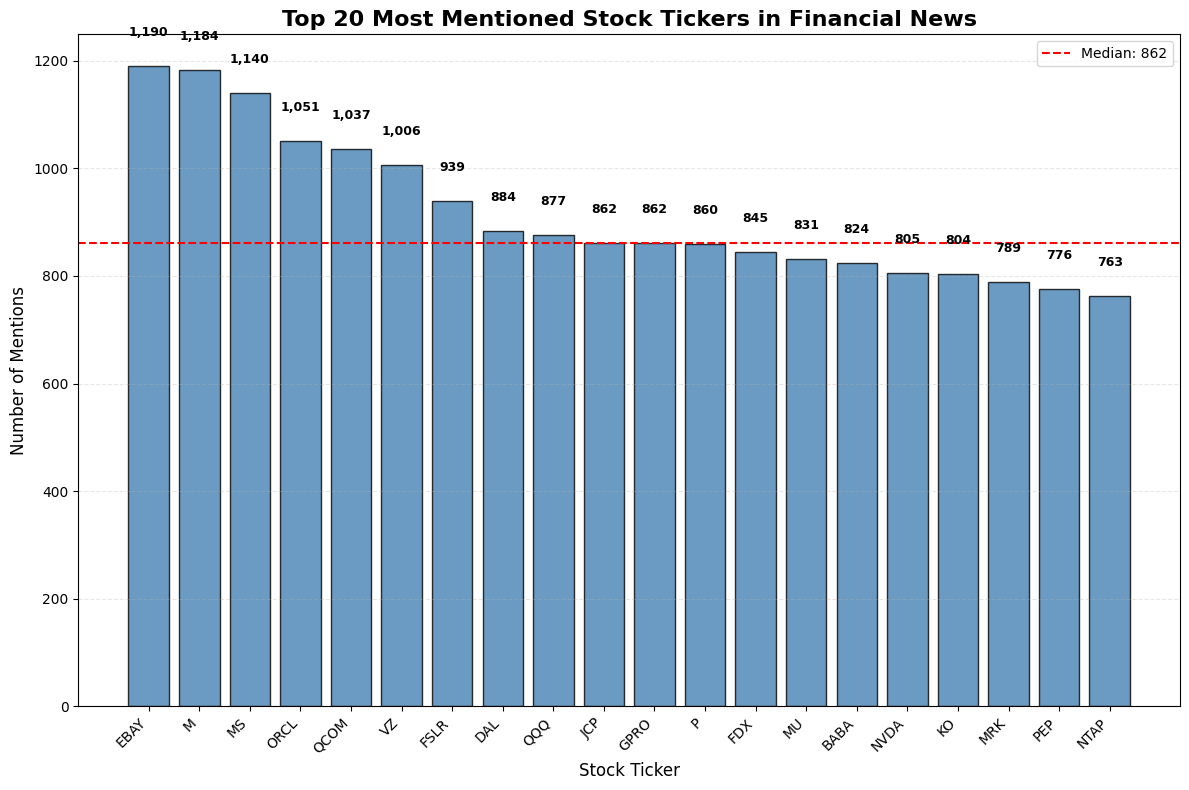


TOP 20 TICKERS SUMMARY:
Total unique tickers mentioned: 3,444
Total mentions across all tickers: 322,993
Top ticker 'EBAY': 1,190 mentions
Top 20 tickers account for: 5.67% of all mentions



In [ ]:
# Get top 20 tickers
top_tickers = news['stock'].value_counts().head(20)

# Create figure with proper size
plt.figure(figsize=(12, 8))

# Create bar chart
bars = plt.bar(range(len(top_tickers)), top_tickers.values,
               color='steelblue', edgecolor='black', alpha=0.8)

# Customize the plot
plt.title('Top 20 Most Mentioned Stock Tickers in Financial News',
          fontsize=16, fontweight='bold')
plt.xlabel('Stock Ticker', fontsize=12)
plt.ylabel('Number of Mentions', fontsize=12)

# Set x-axis ticks to show stock tickers
plt.xticks(range(len(top_tickers)), top_tickers.index, rotation=45, ha='right')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, top_tickers.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{value:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add horizontal line at median for reference
median_val = np.median(top_tickers.values)
plt.axhline(y=median_val, color='red', linestyle='--', linewidth=1.5,
            label=f'Median: {median_val:,.0f}')
plt.legend()

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

# Print summary statistics
print(f"\n{'='*50}")
print("TOP 20 TICKERS SUMMARY:")
print(f"{'='*50}")
print(f"Total unique tickers mentioned: {news['stock'].nunique():,}")
print(f"Total mentions across all tickers: {len(news):,}")
print(f"Top ticker '{top_tickers.index[0]}': {top_tickers.values[0]:,} mentions")
print(f"Top 20 tickers account for: {(top_tickers.sum()/len(news)*100):.2f}% of all mentions")
print(f"{'='*50}\n")

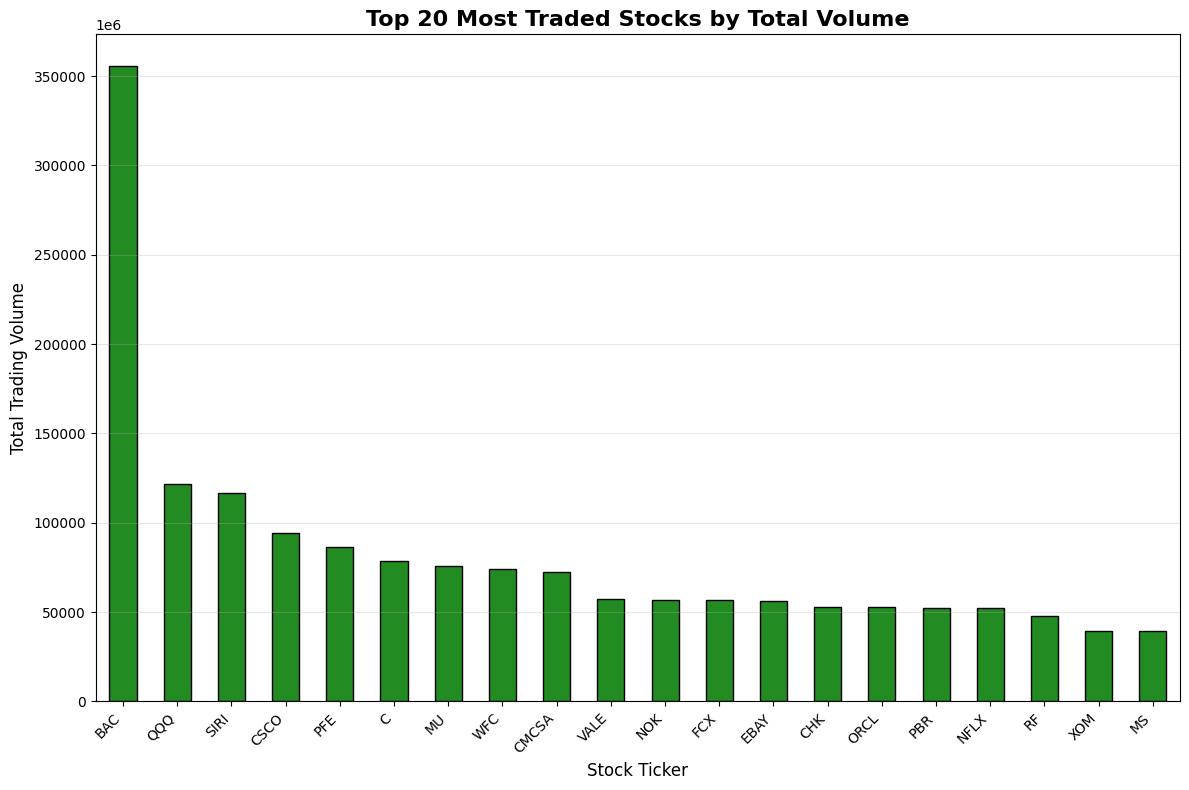

In [ ]:
# Plot the top 20 most traded stocks (by total volume)
plt.figure(figsize=(12, 8))
top_volume = stock.groupby('ticker')['volume'].sum().sort_values(ascending=False).head(20)
top_volume.plot(kind='bar', color='forestgreen', edgecolor='black')

plt.title('Top 20 Most Traded Stocks by Total Volume', fontsize=16, fontweight='bold')
plt.xlabel('Stock Ticker', fontsize=12)
plt.ylabel('Total Trading Volume', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Format y-axis labels to show millions/billions
plt.ticklabel_format(style='scientific', axis='y', scilimits=(6,6))

plt.tight_layout()
plt.show()

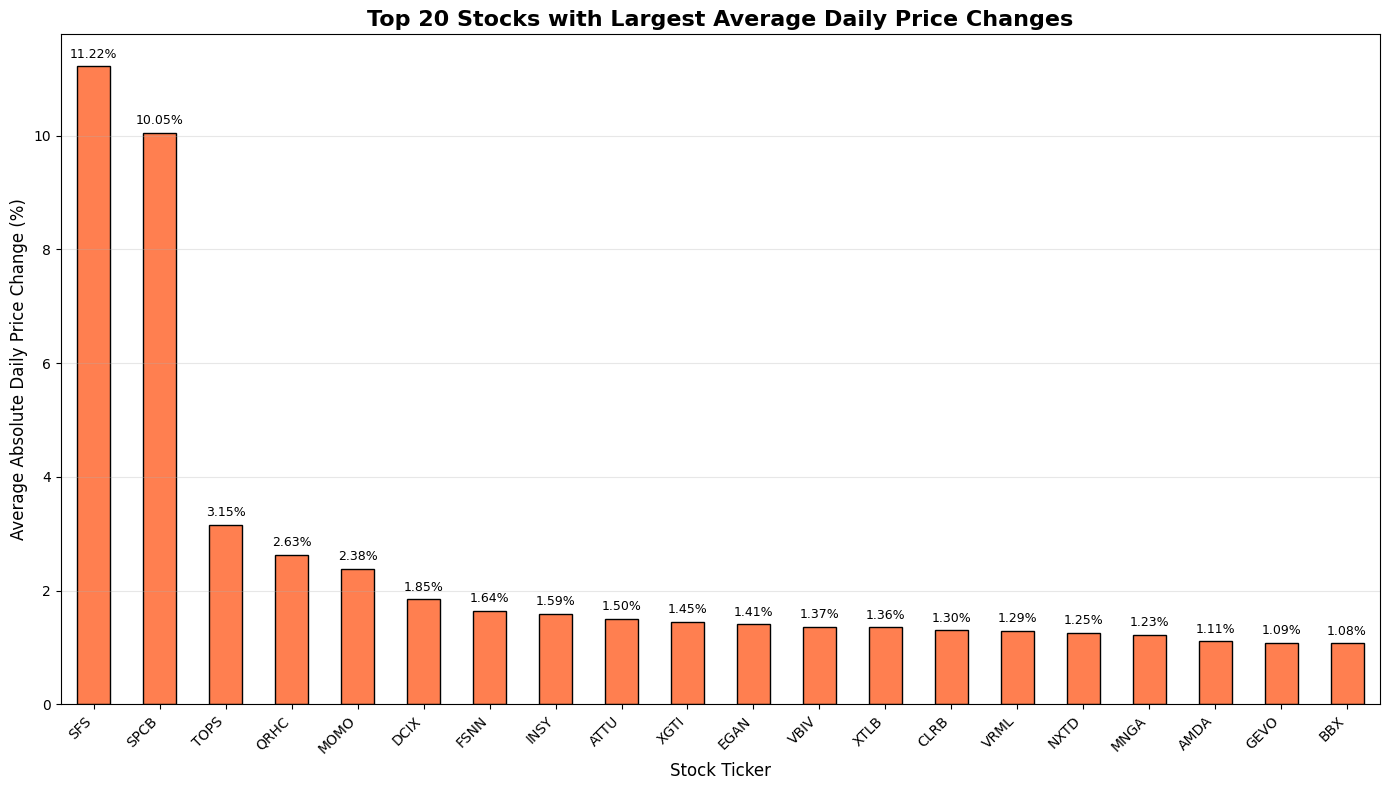

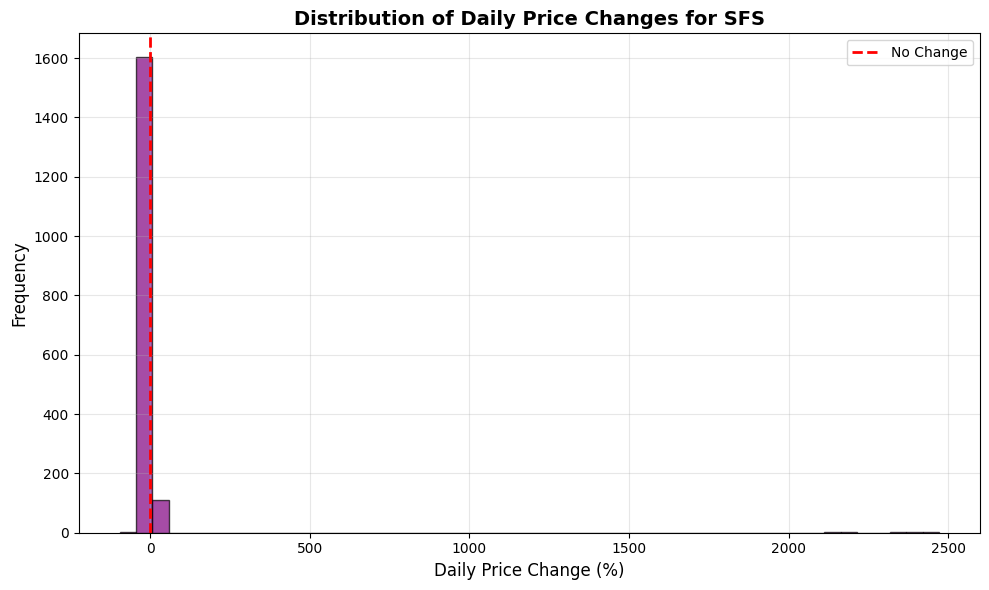

In [ ]:
# plot the top # stocks with the largest price changes within a day
# Calculate daily price change percentage
stock['price_change_pct'] = ((stock['close'] - stock['open']) / stock['open']) * 100

# Get top 20 stocks with largest absolute daily price changes
plt.figure(figsize=(14, 8))

# Average daily price change by ticker
avg_daily_change = stock.groupby('ticker')['price_change_pct'].mean().abs().sort_values(ascending=False).head(20)

avg_daily_change.plot(kind='bar', color='coral', edgecolor='black')

plt.title('Top 20 Stocks with Largest Average Daily Price Changes', fontsize=16, fontweight='bold')
plt.xlabel('Stock Ticker', fontsize=12)
plt.ylabel('Average Absolute Daily Price Change (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_daily_change.values):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Also show the distribution of price changes for a specific stock
# Choose a high-volatility stock from above
example_ticker = avg_daily_change.index[0] if len(avg_daily_change) > 0 else 'AAPL'
stock_example = stock[stock['ticker'] == example_ticker]

plt.figure(figsize=(10, 6))
plt.hist(stock_example['price_change_pct'], bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
plt.title(f'Distribution of Daily Price Changes for {example_ticker}', fontsize=14, fontweight='bold')
plt.xlabel('Daily Price Change (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

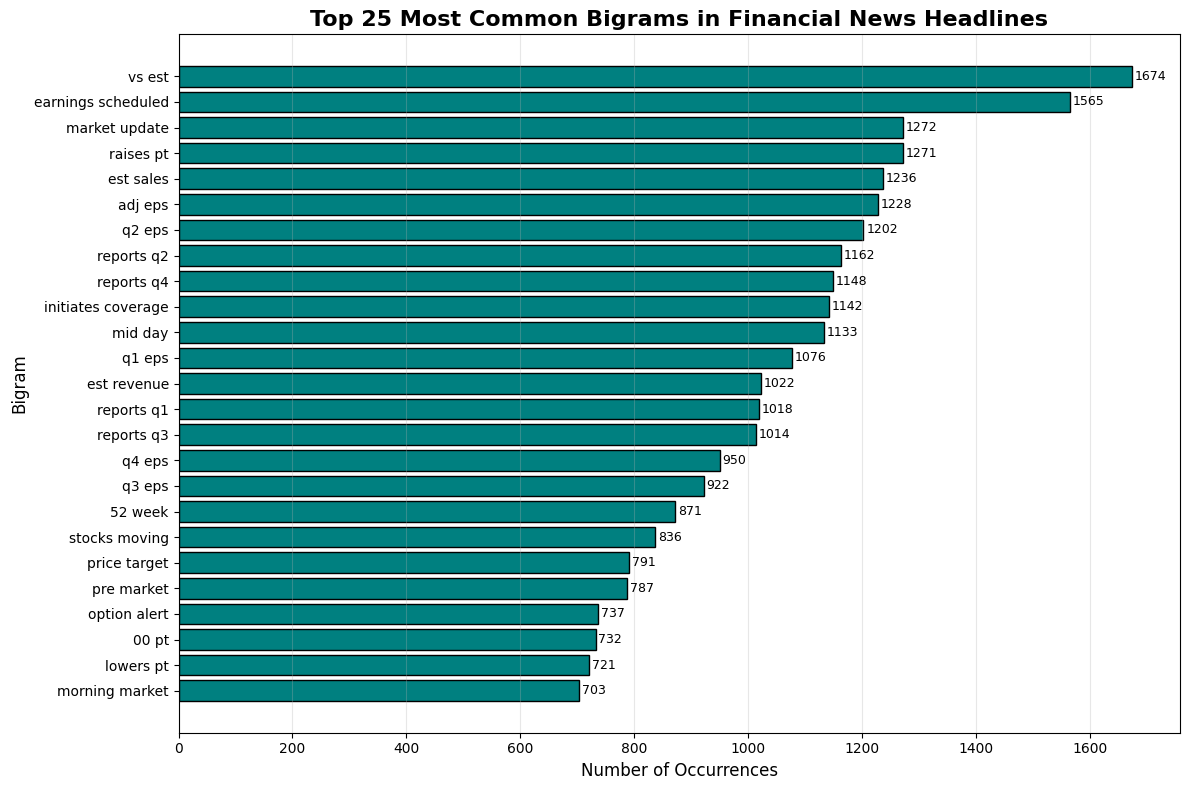

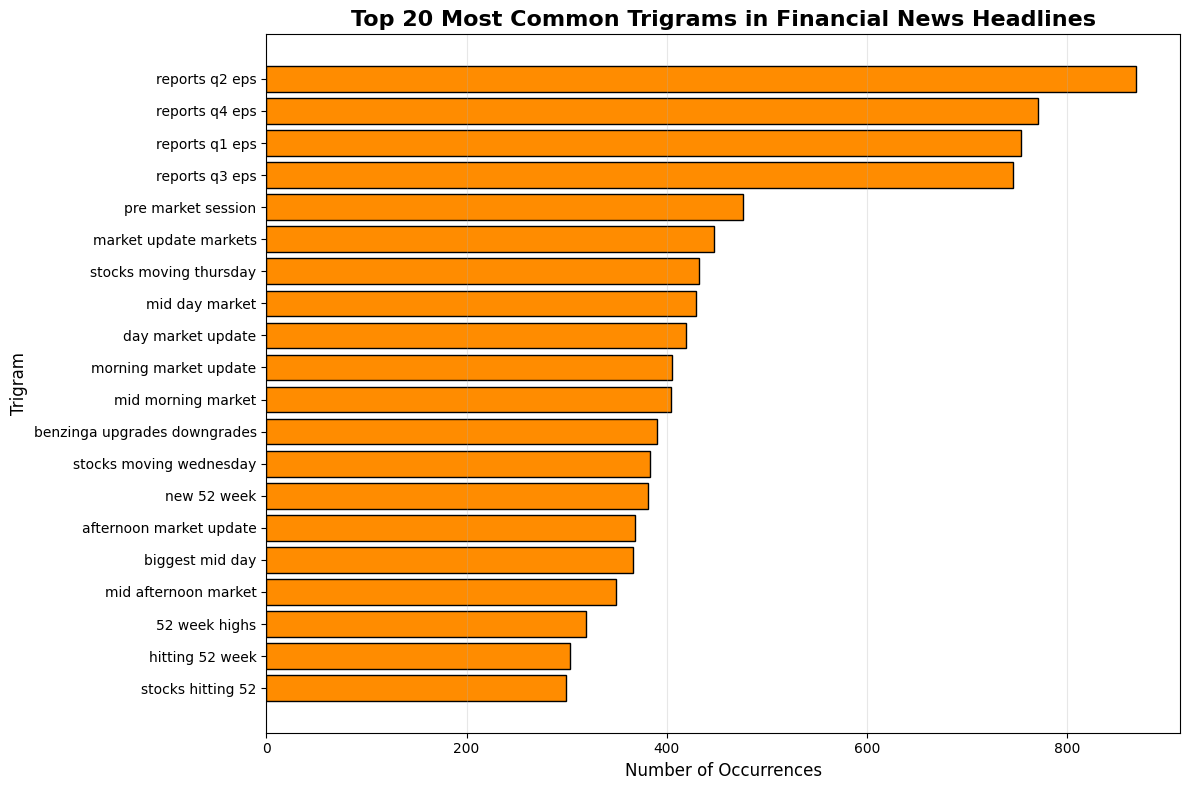

In [ ]:
# plot counts of top bigrams (n-grams)
# Plot counts of top bigrams (n-grams)
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

# Prepare headlines (sample to manage memory)
headlines = news['title'].dropna().astype(str)
sample_size = min(50000, len(headlines))
headline_sample = headlines.sample(n=sample_size, random_state=42)

# Create bigram vectorizer
bigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2),
    max_features=25,
    min_df=5
)

bigram_matrix = bigram_vectorizer.fit_transform(headline_sample)
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()
bigram_df = pd.DataFrame({
    'bigram': bigram_vectorizer.get_feature_names_out(),
    'count': bigram_counts
}).sort_values('count', ascending=False)

# Plot top bigrams
plt.figure(figsize=(12, 8))
bigram_df_sorted = bigram_df.sort_values('count', ascending=True)
plt.barh(bigram_df_sorted['bigram'], bigram_df_sorted['count'], color='teal', edgecolor='black')

plt.title('Top 25 Most Common Bigrams in Financial News Headlines', fontsize=16, fontweight='bold')
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Bigram', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(bigram_df_sorted['count']):
    plt.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Also show trigrams for additional insight
trigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(3, 3),
    max_features=20,
    min_df=3
)

trigram_matrix = trigram_vectorizer.fit_transform(headline_sample)
trigram_counts = np.asarray(trigram_matrix.sum(axis=0)).ravel()
trigram_df = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts
}).sort_values('count', ascending=False)

# Plot top trigrams
plt.figure(figsize=(12, 8))
trigram_df_sorted = trigram_df.sort_values('count', ascending=True)
plt.barh(trigram_df_sorted['trigram'], trigram_df_sorted['count'], color='darkorange', edgecolor='black')

plt.title('Top 20 Most Common Trigrams in Financial News Headlines', fontsize=16, fontweight='bold')
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Trigram', fontsize=12)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

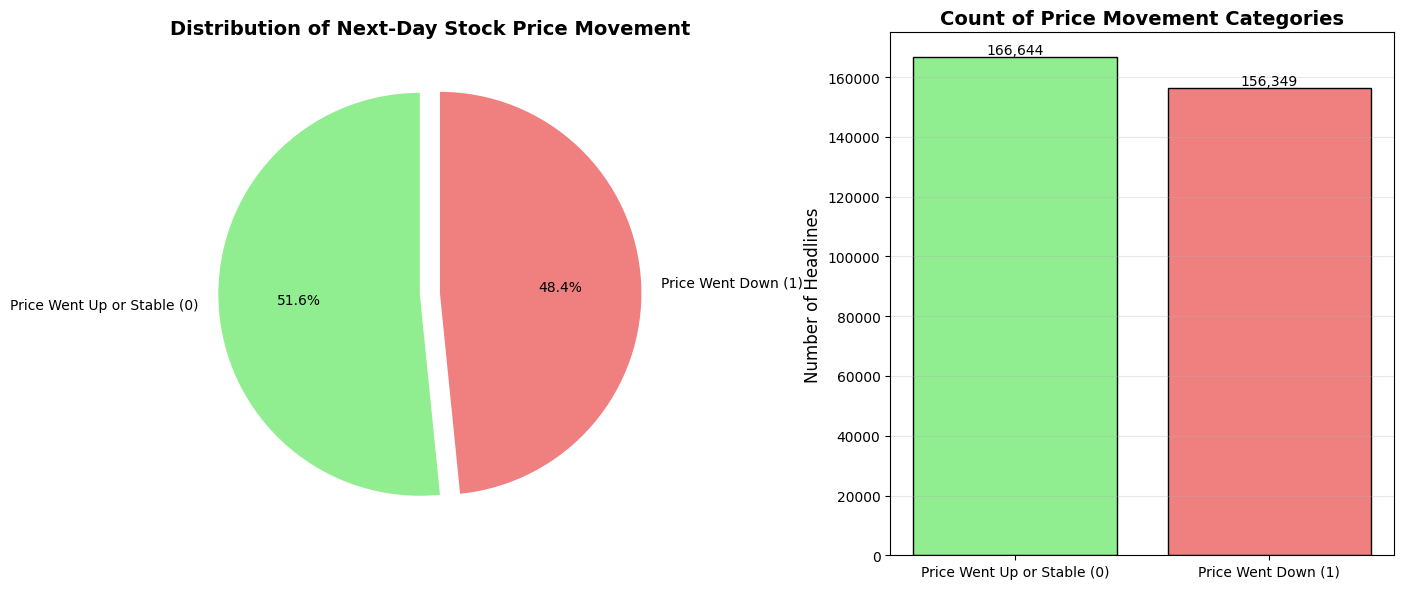

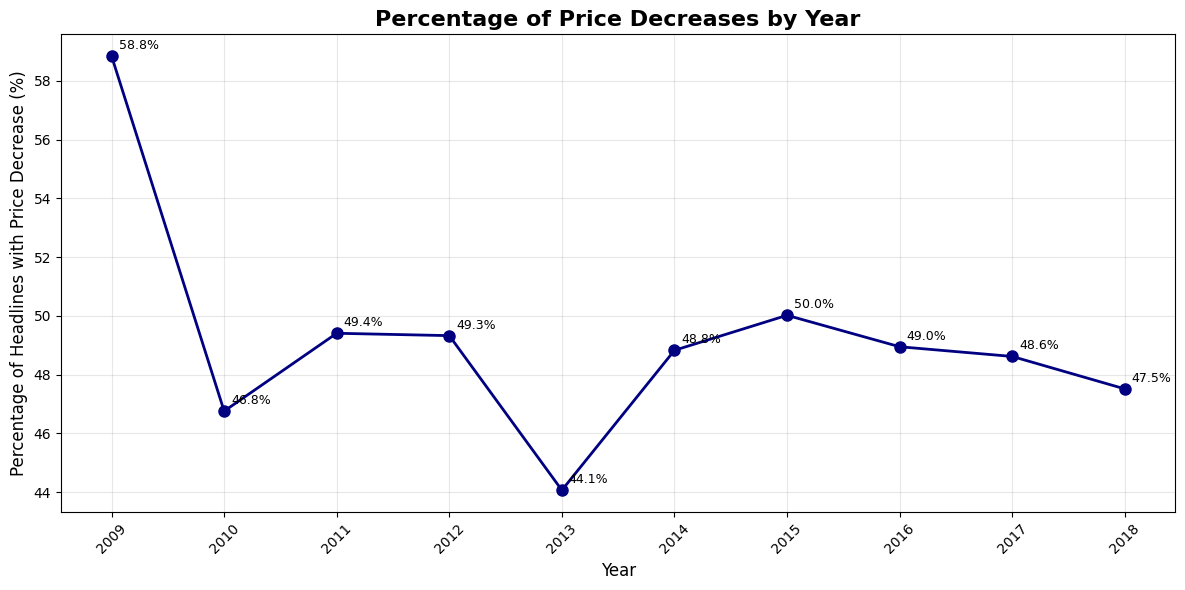

In [ ]:
# plot price_went_up column
# Plot price_went_up column
plt.figure(figsize=(12, 6))

# Create subplots for better visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
price_counts = news['price_went_up'].value_counts()
labels = ['Price Went Up or Stable (0)', 'Price Went Down (1)']
colors = ['lightgreen', 'lightcoral']
ax1.pie(price_counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0.05, 0.05))
ax1.set_title('Distribution of Next-Day Stock Price Movement', fontsize=14, fontweight='bold')

# Bar chart
bars = ax2.bar(labels, price_counts.values, color=colors, edgecolor='black')
ax2.set_title('Count of Price Movement Categories', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Headlines', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, price_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Additional analysis - price movement by year
news['year'] = news['date'].dt.year
yearly_movement = news.groupby('year')['price_went_up'].mean() * 100

plt.figure(figsize=(12, 6))
yearly_movement.plot(kind='line', marker='o', linewidth=2, markersize=8, color='navy')
plt.title('Percentage of Price Decreases by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Headlines with Price Decrease (%)', fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(yearly_movement.index, rotation=45)

# Add value labels
for year, value in yearly_movement.items():
    plt.annotate(f'{value:.1f}%', (year, value),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# other plots you deem fit


### Exploratory Data Analysis

In [ ]:
# Exploratory Data Analysis
# Uses copies so the original dataframes are not modified

eda_news = news.copy()
eda_stock = stock.copy()

print(f"Number of cleaned news headlines: {len(eda_news):,}")
print(f"Number of stock-price records: {len(eda_stock):,}")
print(f"Number of companies in news data: {eda_news['stock'].nunique():,}")
print(f"News date range: {eda_news['date'].min()} to {eda_news['date'].max()}")

Number of cleaned news headlines: 322,993
Number of stock-price records: 7,523,764
Number of companies in news data: 3,444
News date range: 2009-04-29 00:00:00 to 2018-08-23 00:00:00


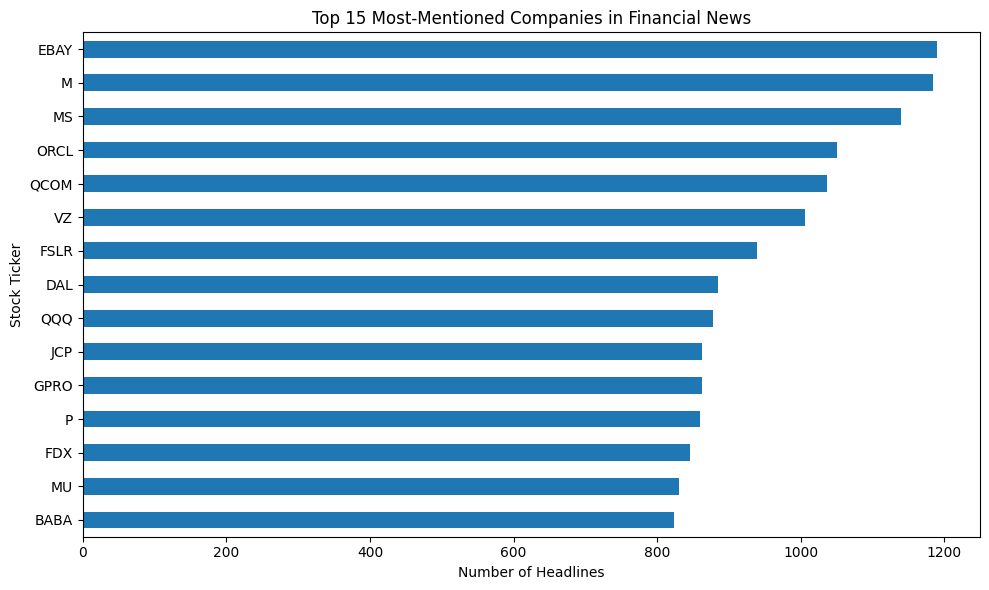

In [ ]:
top_mentions = eda_news["stock"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_mentions.sort_values().plot(kind="barh")

plt.title("Top 15 Most-Mentioned Companies in Financial News")
plt.xlabel("Number of Headlines")
plt.ylabel("Stock Ticker")
plt.tight_layout()
plt.show()

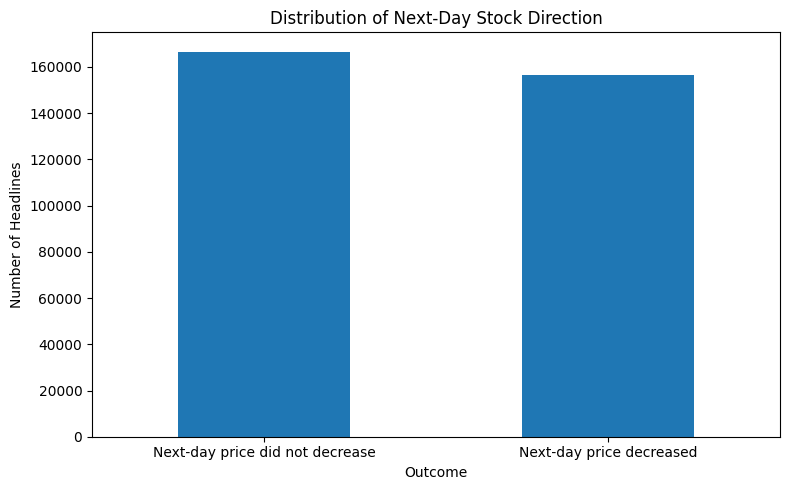

price_went_up
0    0.515937
1    0.484063
Name: proportion, dtype: float64


In [ ]:
target_counts = (
    eda_news["price_went_up"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

target_counts.index = [
    "Next-day price did not decrease",
    "Next-day price decreased"
]

plt.figure(figsize=(8, 5))
target_counts.plot(kind="bar")

plt.title("Distribution of Next-Day Stock Direction")
plt.xlabel("Outcome")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(
    eda_news["price_went_up"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
)

The target classes are nearly balanced, with approximately 51.6% of headlines associated with no next-day decrease and 48.4% associated with a decrease. This reduces concerns that a model could achieve misleadingly high accuracy by mainly predicting one class.

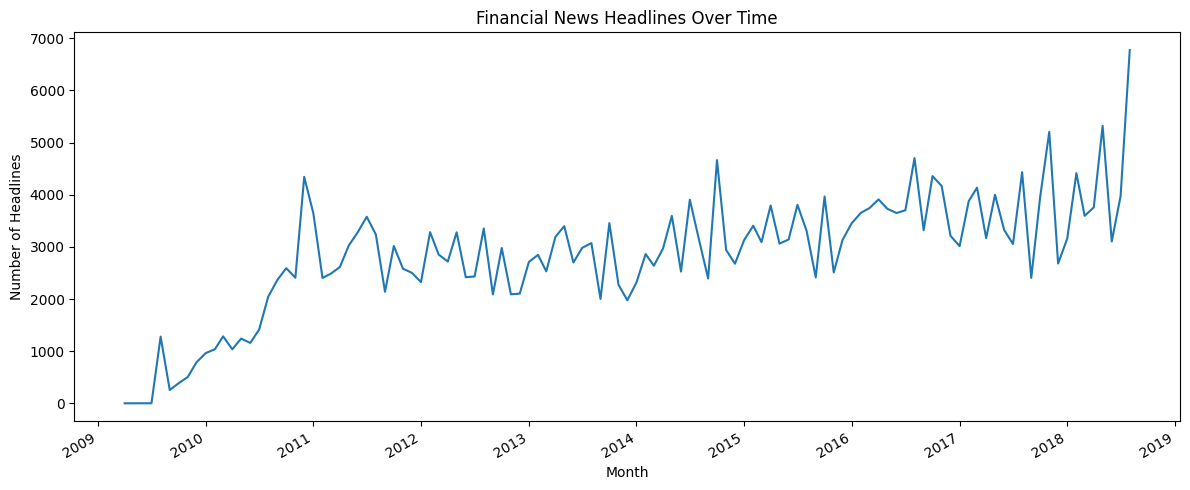

In [ ]:
monthly_news = (
    eda_news.assign(
        month=eda_news["date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("month")
    .size()
)

plt.figure(figsize=(12, 5))
monthly_news.plot()

plt.title("Financial News Headlines Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Headlines")
plt.tight_layout()
plt.show()

The number of available headlines generally increases over time, so later years are more heavily represented. This should be considered when splitting the data because a random split may mix earlier and later market periods.

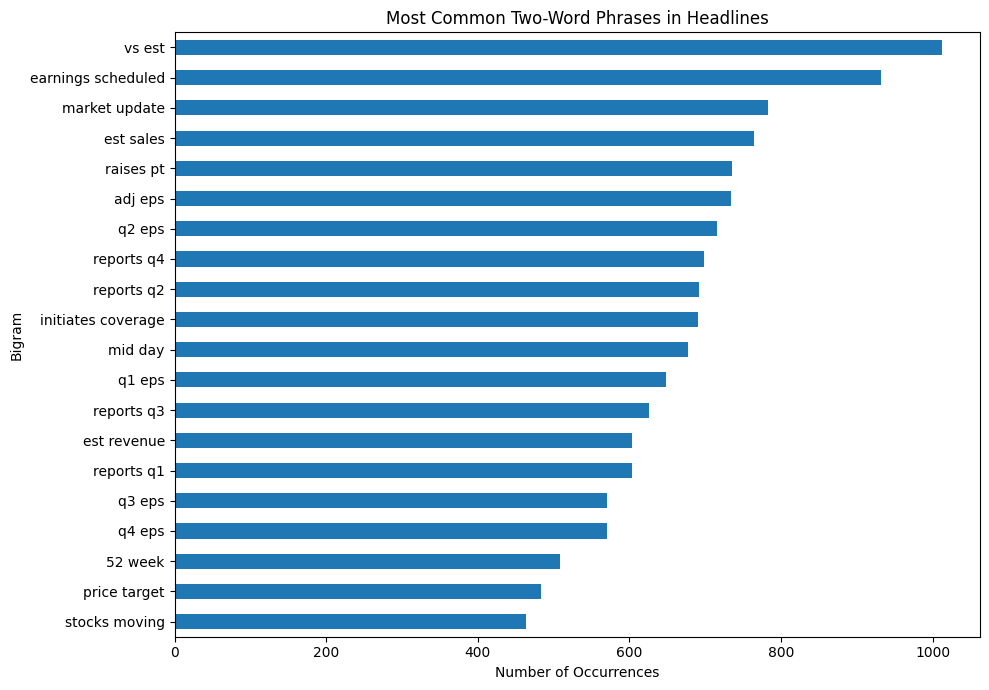

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

headlines = eda_news["title"].dropna().astype(str)

# Sampling prevents the vectorizer from using excessive memory
sample_size = min(30000, len(headlines))
headline_sample = headlines.sample(
    n=sample_size,
    random_state=42
)

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20,
    min_df=3
)

bigram_matrix = bigram_vectorizer.fit_transform(headline_sample)

bigram_counts = np.asarray(
    bigram_matrix.sum(axis=0)
).ravel()

bigram_df = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_counts
}).sort_values("count", ascending=False)


bigram_df.sort_values("count").plot(
    x="bigram",
    y="count",
    kind="barh",
    legend=False,
    figsize=(10, 7)
)

plt.title("Most Common Two-Word Phrases in Headlines")
plt.xlabel("Number of Occurrences")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

The most common bigrams focus heavily on earnings reports, analyst estimates, and price-target updates. These repeated financial phrases may provide useful predictive signals, but they may also reflect templated reporting patterns in the source dataset.

##FINBert

In [ ]:
finbert = pipeline(
    "text-classification",
    model = "ProsusAI/finbert"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
news = news.sample(50000, random_state=6).reset_index(drop=True)

In [ ]:
headlines = news['title'].tolist()

results = finbert(
    headlines,
    batch_size = 32,
    truncation = True
)

news['sentitment'] = [r['label'] for r in results]
news['confidence'] = [r['score'] for r in results]

news

,title,date,stock,today_price,1ago_price,2ago_price,nextday_price,price_went_up,year,sentitment,confidence
1828,Going Against the Herd,2009-04-29,A,12.8970,12.1888,12.1030,13.0615,0,2009,neutral,0.797031
706794,Another must watch: Glenn Beck explains the Go...,2009-07-16,K,47.9900,47.9400,47.7500,47.1800,1,2009,neutral,0.922760
1825,The Gold/Silver Ratio From 1300 to 1900...And Now,2009-07-30,A,16.5665,16.1874,16.6595,16.6094,0,2009,neutral,0.915127
208250,Brampton Brick Reports Results for the Second ...,2009-08-06,CASH,23.5000,22.4400,22.9100,22.2200,1,2009,neutral,0.870270
1290563,Univest Corporation of Pennsylvania Announces ...,2009-08-06,UVSP,19.1500,19.6500,20.4200,20.6300,0,2009,neutral,0.933314
...,...,...,...,...,...,...,...,...,...,...,...
127947,"Alibaba CEO Daniel Zhang Says, 'We will contin...",2018-08-23,BABA,172.2300,177.8500,177.9200,174.2300,0,2018,positive,0.920498
127936,Have You Tried The New Benzinga Pro Chat Beta ...,2018-08-23,BABA,172.2300,177.8500,177.9200,174.2300,0,2018,neutral,0.941899
1100158,Sanderson Farms CEO On Conf. Call Says They No...,2018-08-23,SAFM,106.4700,106.7100,104.0700,109.2500,0,2018,positive,0.697234
1304282,"Ahead Of Earnings, VMware Looks Ready To Breakout",2018-08-23,VMW,154.7700,154.2800,151.6800,151.3700,1,2018,positive,0.766100


##Data Spliting

In [ ]:
X = news.drop('price_went_up', axis=1)
y = news['price_went_up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6, stratify=y)

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

SENTIMENT_MAP = {'positive': 1, 'neutral': 0, 'negative': -1}
SENT_COL = 'sentitment'  # FINBert typo in this notebook

def prepare_features(df):
    f = df.copy()
    # Competitive Pressure Index — novel feature tied to project theme
    if 'stock' in f.columns and 'date' in f.columns and 'title' in f.columns:
        daily_n = f.groupby(['stock', 'date'])['title'].transform('count')
        avg_n   = f.groupby('stock')['title'].transform('count') / max(f['date'].nunique(), 1)
        sent    = f[SENT_COL].map(SENTIMENT_MAP).fillna(0) if SENT_COL in f.columns else 0
        f['news_surge_ratio']           = daily_n / avg_n.replace(0, 1)
        f['competitive_pressure_index'] = f['news_surge_ratio'] * (sent * -1)
    # Drop leakage + non-numeric columns
    f = f.drop(columns=[c for c in ['nextday_price', 'title', 'date', 'stock'] if c in f.columns])
    # Encode sentiment to numeric
    if SENT_COL in f.columns:
        f['sentiment_score'] = f[SENT_COL].map(SENTIMENT_MAP).fillna(0)
        f = f.drop(columns=[SENT_COL])
    # Price momentum features
    if {'today_price', '1ago_price'}.issubset(f.columns):
        f['price_change_1d']     = f['today_price'] - f['1ago_price']
        f['price_pct_change_1d'] = (f['price_change_1d'] / f['1ago_price'].replace(0, np.nan)).fillna(0)
    if {'today_price', '2ago_price'}.issubset(f.columns):
        f['price_change_2d'] = f['today_price'] - f['2ago_price']
    return f.fillna(0)

X_train_rf = prepare_features(X_train)
X_test_rf  = prepare_features(X_test)

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_model.fit(X_train_rf, y_train)
y_pred_rf = rf_model.predict(X_test_rf)
print("Random Forest trained. Features:", X_train_rf.columns.tolist())

Random Forest trained. Features: ['today_price', '1ago_price', '2ago_price', 'year', 'confidence', 'news_surge_ratio', 'competitive_pressure_index', 'sentiment_score', 'price_change_1d', 'price_pct_change_1d', 'price_change_2d']


###cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf = cross_val_score(rf_model, X_train_rf, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"RF Cross-Validation (5-fold): {cv_rf.round(4)}")
print(f"Mean: {cv_rf.mean():.4f}  Std: {cv_rf.std():.4f}")

RF Cross-Validation (5-fold): [0.5477 0.5512 0.5487 0.5486 0.5466]
Mean: 0.5485  Std: 0.0015


###accuracy

Random Forest Accuracy: 0.5442

Classification Report:
                        precision    recall  f1-score   support

Price Did Not Decrease       0.54      0.80      0.65     33329
       Price Decreased       0.56      0.27      0.36     31270

              accuracy                           0.54     64599
             macro avg       0.55      0.54      0.50     64599
          weighted avg       0.55      0.54      0.51     64599



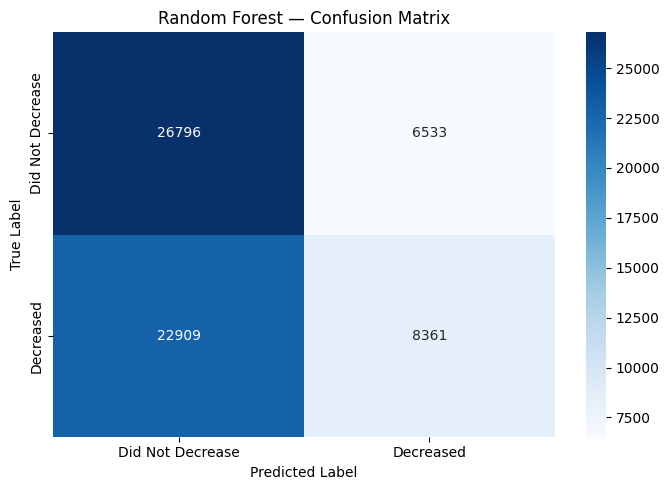

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Price Did Not Decrease', 'Price Decreased']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Decrease', 'Decreased'],
            yticklabels=['Did Not Decrease', 'Decreased'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

##Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
lr_model.fit(X_train_rf, y_train)
y_pred_lr = lr_model.predict(X_test_rf)
print("Logistic Regression trained.")

Logistic Regression trained.


###cross validation

In [ ]:
cv_lr = cross_val_score(lr_model, X_train_rf, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
print(f"LR Cross-Validation (5-fold): {cv_lr.round(4)}")
print(f"Mean: {cv_lr.mean():.4f}  Std: {cv_lr.std():.4f}")

LR Cross-Validation (5-fold): [0.507  0.5075 0.5066 0.5088 0.5039]
Mean: 0.5068  Std: 0.0016


###accuracy

Logistic Regression Accuracy: 0.5075

Classification Report:
                        precision    recall  f1-score   support

Price Did Not Decrease       0.53      0.41      0.46     33329
       Price Decreased       0.49      0.61      0.55     31270

              accuracy                           0.51     64599
             macro avg       0.51      0.51      0.50     64599
          weighted avg       0.51      0.51      0.50     64599



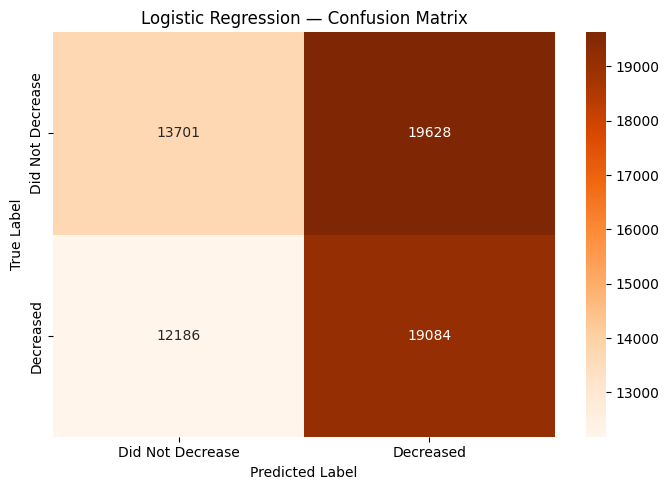


RF Accuracy:  0.5442
LR Accuracy:  0.5075


In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Price Did Not Decrease', 'Price Decreased']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Did Not Decrease', 'Decreased'],
            yticklabels=['Did Not Decrease', 'Decreased'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n" + "="*40)
print(f"RF Accuracy:  {rf_accuracy:.4f}")
print(f"LR Accuracy:  {lr_accuracy:.4f}")
print("="*40)